# Reconstrução de sinais: seno e periódico aleatório

**Aluno:** Murilo &nbsp;|&nbsp; INF0413 - Processamento Digital de Sinais, 2026-2

1. Crie um sinal seno com frequência e duração controladas (sem fs)
2. Crie um sinal periódico aleatório com frequência e duração controladas (sem fs)
3. Mostre os plots do sinal em amostras, $x[n]$, e no tempo, $x(t)$

A ideia do "sem fs": a frequência do sinal é controlada pelo **período M em amostras**.
Isso não depende de fs. A fs só entra em dois momentos: para transformar a duração
em segundos em número de amostras, e para tocar o som.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('.')
from lib.myPlotLib import *
from lib.myAudioProcessingLib import * # <- A nossa biblioteca de processamento de áudio

In [3]:
def create_sine_signal(M, A=1.0, phi= 0.0, fs=48e3, dur=1.0):
    """
    M  : period (samples)
    A  : amplitude
    phi: phase
    dur: duration (seconds)
    fs : sampling frequency (Hz)
    """

    N = int(dur * fs)                            # numero de amostras = duracao x fs
    n = np.arange(N)                             # vetor de amostras 0, 1, ..., N-1
    x = A * np.sin(2 * np.pi * n / M + phi)      # um ciclo completo a cada M amostras

    return x, n

In [4]:
M   = 48        # periodo em amostras -> frequencia digital wo = 2*pi/M
fs  = 48000     # Hz
dur = 1.0       # segundos
A   = 0.5       # amplitude (0.5 para nao estourar o volume)
phi = 0.0       # fase

x, n = create_sine_signal(M, A, phi, fs, dur)

# A frequencia em Hz so aparece quando escolhemos fs: f = fs / M
print(f'{len(x)} amostras | wo = 2*pi/M = {2*np.pi/M:.4f} rad/amostra | f = fs/M = {fs/M:.0f} Hz')

48000 amostras | wo = 2*pi/M = 0.1309 rad/amostra | f = fs/M = 1000 Hz


In [5]:
play(x, fs)

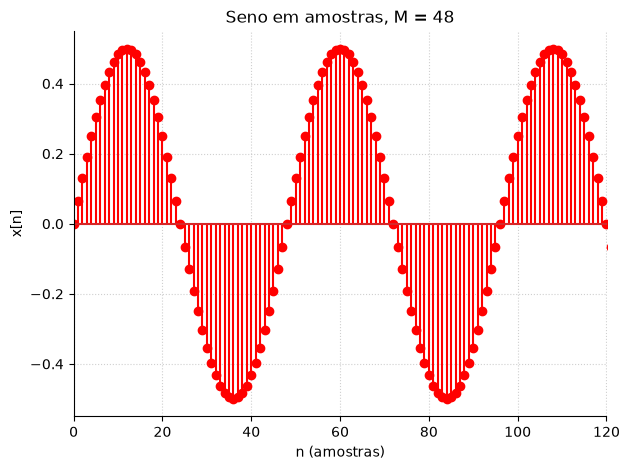

In [6]:
# Plot em amostras: x[n]
fig, ax = plt.subplots()
ax.stem(n, x, 'r')
ax.set_xlim([0, 2.5 * M])                 # mostra 2,5 periodos
ax.set_xlabel('n (amostras)'); ax.set_ylabel('x[n]')
ax.set_title(f'Seno em amostras, M = {M}')
figureFormat(ax, fig, tight=True)
plt.show()

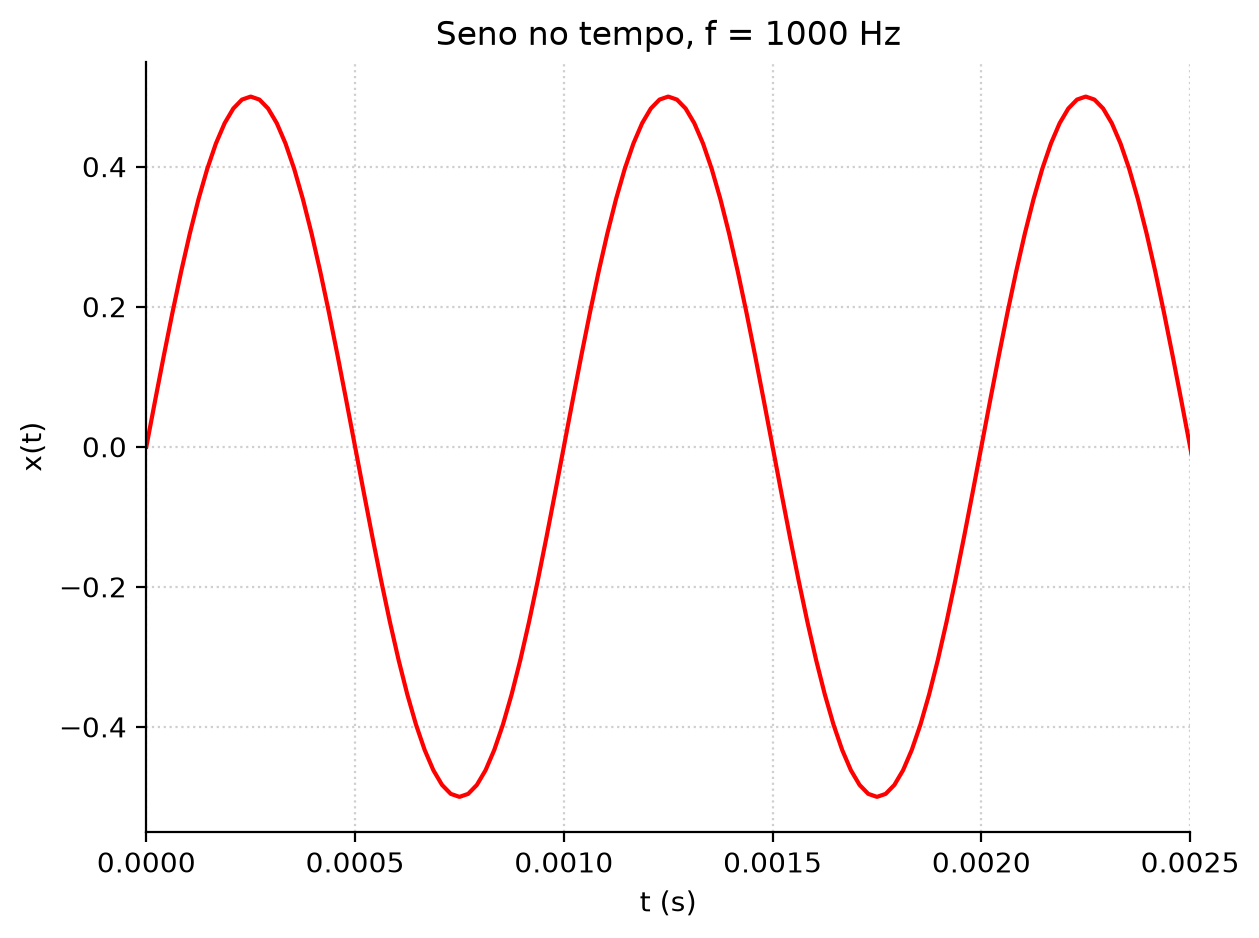

In [7]:
# Plot no tempo: x(t), com t = n / fs
t = n / fs

fig, ax = plt.subplots()
ax.plot(t, x, 'r')
ax.set_xlim([0, 2.5 * M / fs])            # os mesmos 2,5 periodos, agora em segundos
ax.set_xlabel('t (s)'); ax.set_ylabel('x(t)')
ax.set_title(f'Seno no tempo, f = {fs/M:.0f} Hz')
figureFormat(ax, fig, tight=True)
plt.show()

# Mesmo sinal, mesmos numeros. So o eixo mudou: n vira t dividindo por fs.
# Um periodo sao M amostras, que duram M/fs segundos.

## Controlando a frequência só pelo período M

Com a mesma fs, mudar M muda a nota: M maior = mais amostras por ciclo = som mais grave.

In [8]:
for M_i in [24, 48, 96]:
    x_i, _ = create_sine_signal(M_i, A, phi, fs, dur)
    print(f'M = {M_i:3d} amostras  ->  f = fs/M = {fs/M_i:5.0f} Hz')
    play(x_i, fs)

M =  24 amostras  ->  f = fs/M =  2000 Hz


M =  48 amostras  ->  f = fs/M =  1000 Hz


M =  96 amostras  ->  f = fs/M =   500 Hz


## 2. Sinal periódico aleatório

Sorteio **um período** de M amostras aleatórias e repito esse mesmo pedaço até
completar a duração. O sinal continua periódico (se repete a cada M amostras),
então tem a mesma frequência do seno com o mesmo M, mas a forma de cada ciclo é
outra.

In [9]:
def create_random_periodic_signal(M, A=1.0, fs=48e3, dur=1.0, seed=None):
    """
    M   : period (samples)
    A   : amplitude
    fs  : sampling frequency (Hz)
    dur : duration (seconds)
    seed: semente do sorteio (para repetir o mesmo resultado)
    """

    N = int(dur * fs)
    n = np.arange(N)

    np.random.seed(seed)
    periodo = np.random.uniform(-1, 1, M)          # um periodo com M amostras aleatorias
    repeticoes = int(np.ceil(N / M))               # quantas vezes repetir para dar N amostras
    x = A * np.tile(periodo, repeticoes)[:N]       # cola o periodo varias vezes e corta em N

    return x, n

In [10]:
xr, nr = create_random_periodic_signal(M, A, fs, dur, seed=0)

print(f'{len(xr)} amostras | periodo M = {M} | f = fs/M = {fs/M:.0f} Hz')
play(xr, fs)

48000 amostras | periodo M = 48 | f = fs/M = 1000 Hz


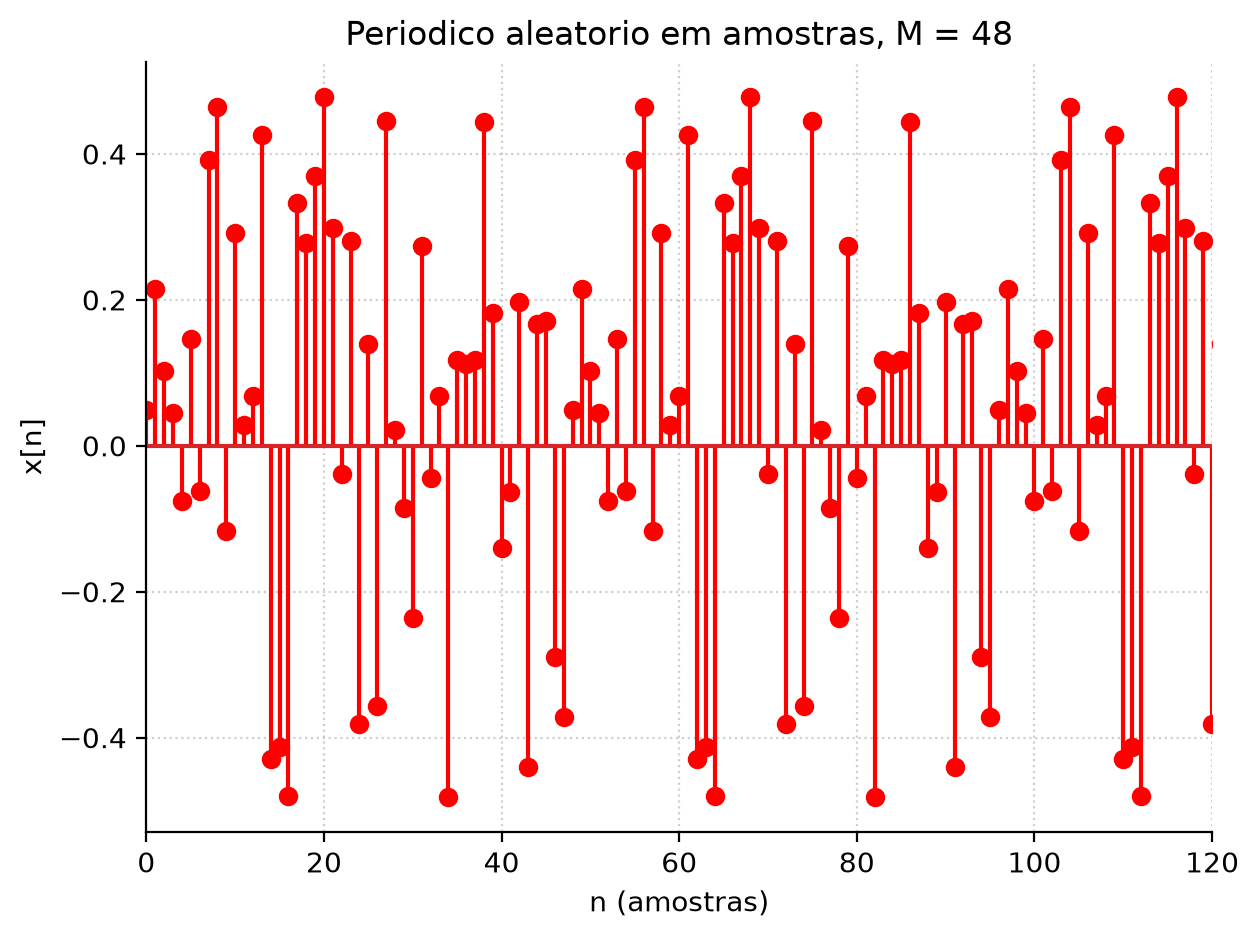

In [11]:
# Plot em amostras: xr[n]
fig, ax = plt.subplots()
ax.stem(nr, xr, 'r')
ax.set_xlim([0, 2.5 * M])
ax.set_xlabel('n (amostras)'); ax.set_ylabel('x[n]')
ax.set_title(f'Periodico aleatorio em amostras, M = {M}')
figureFormat(ax, fig, tight=True)
plt.show()

# Da para ver o mesmo desenho se repetindo a cada 48 amostras.

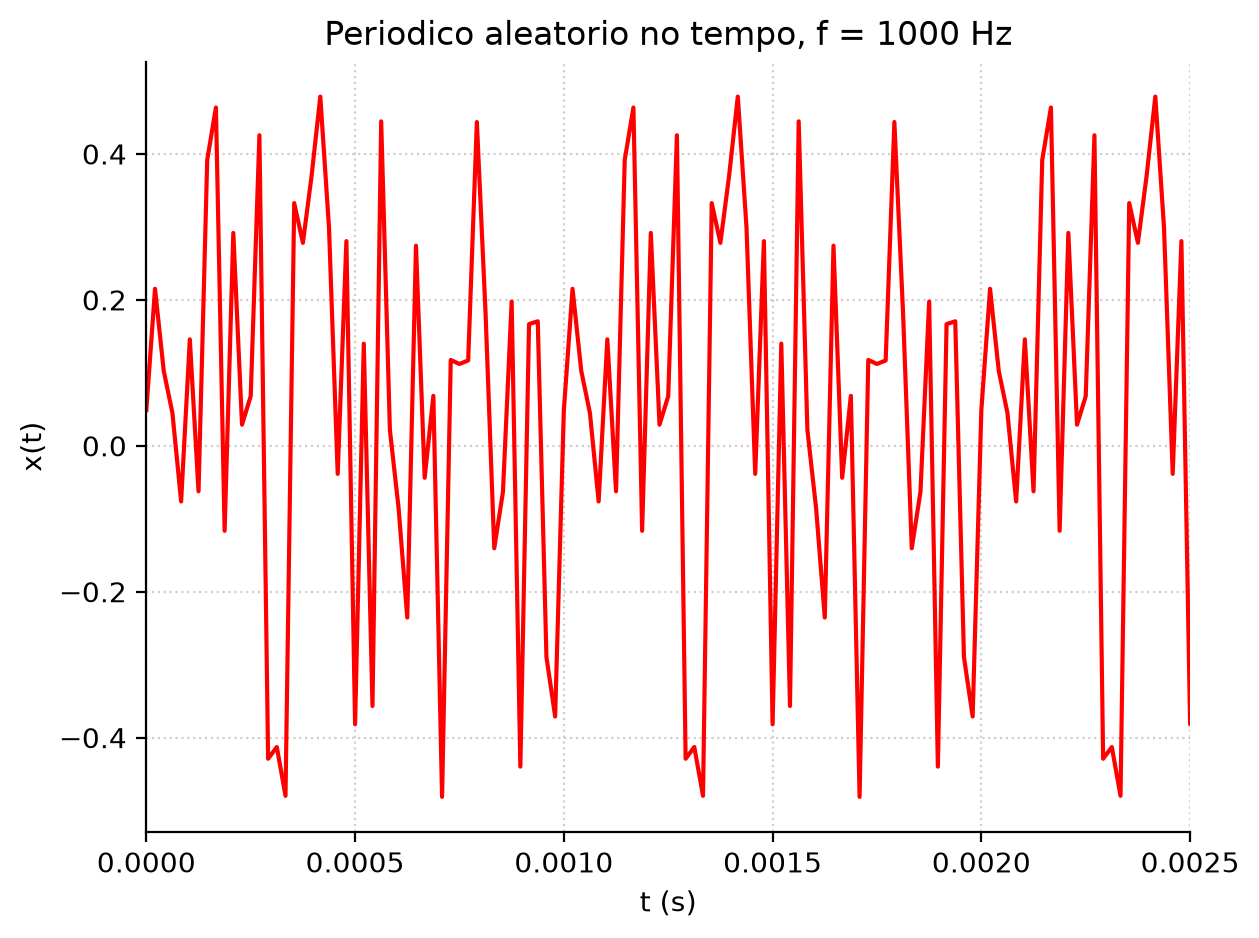

In [12]:
# Plot no tempo: xr(t)
tr = nr / fs

fig, ax = plt.subplots()
ax.plot(tr, xr, 'r')
ax.set_xlim([0, 2.5 * M / fs])
ax.set_xlabel('t (s)'); ax.set_ylabel('x(t)')
ax.set_title(f'Periodico aleatorio no tempo, f = {fs/M:.0f} Hz')
figureFormat(ax, fig, tight=True)
plt.show()

## Comparando os dois com o mesmo M

Mesma frequência (mesmo período), timbres diferentes.

In [13]:
print('Seno, M = 48:');               play(x, fs)
print('Periodico aleatorio, M = 48:'); play(xr, fs)

# Os dois tem a mesma "nota" (1000 Hz), porque o periodo e o mesmo.
# O seno so tem a frequencia fundamental; o aleatorio tem a fundamental mais
# varios harmonicos (multiplos de 1000 Hz), por isso soa mais "aspero", parecido
# com uma corda ou um sintetizador. E essa a ideia por tras do algoritmo
# Karplus-Strong do proximo notebook: repetir um buffer aleatorio para fazer nota.

Seno, M = 48:


Periodico aleatorio, M = 48:


## O que aprendi

- A frequência de um sinal digital é dada pelo período M em amostras ($\omega_0 = 2\pi/M$). Não precisa de fs.
- A fs entra só para converter duração em amostras ($N = \text{dur} \cdot f_s$) e para dizer a frequência em Hz ($f = f_s / M$).
- Plotar em amostras ou no tempo é o mesmo sinal, só muda o eixo: $t = n / f_s$.
- Qualquer bloco de M amostras repetido vira um sinal periódico com a mesma nota do seno de período M, mas com outro timbre.